Sztuczne sieci neuronowe i algorytmy uczenia głębokiego | Pracownia specjalistyczna 5-6 - Perceptron wielowarstwowy

Adam Dobrogowski PS7

----------------------------------------

Zadanie nr 1

Wykorzystując poniższy kod utwórz perceptron wielowarstwowy do analizy zbioru MNIST. Przeanalizuj poszczególne fragmenty kodu.


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt

mnist = tf.keras.datasets.mnist 

(x_train,  y_train), (x_test, y_test) = mnist.load_data()

In [2]:
print(f"Wymiar danych uczących (x_train): {x_train.shape}")
print(f"Wymiar etykiet uczących (y_train): {y_train.shape}")
print(f"Wymiar danych testowych (x_test): {x_test.shape}")

Wymiar danych uczących (x_train): (60000, 28, 28)
Wymiar etykiet uczących (y_train): (60000,)
Wymiar danych testowych (x_test): (10000, 28, 28)


1. Jaki jest wymiar danych uczących i testowych?  Dane uczące to 60 000 obrazów 28x28, dane testowe to 10 000 obrazów o tym samym rozmiarze.
--------------------------------
2. Narysuj dowolny obraz z danych uczących oraz wyświetl informację o wartości wzorca dla
tego obrazu:


Text(0.5, 1.0, 'Wartość wzorca (etykieta): 5')

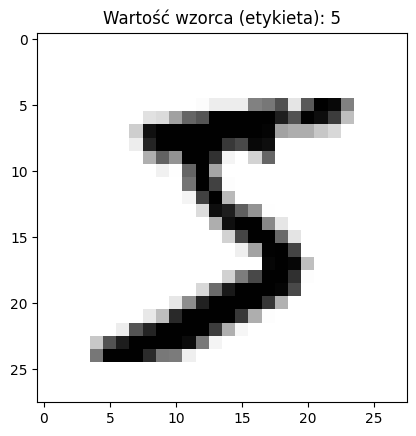

In [3]:
plt.imshow(x_train[0], cmap=plt.cm.binary) 
plt.title(f"Wartość wzorca (etykieta): {y_train[0]}") 

----------------------------------

In [5]:
x_train = tf.keras.utils.normalize(x_train, axis=1)
x_test = tf.keras.utils.normalize(x_test, axis=1)

model = tf.keras.models.Sequential() 

model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(128, activation='relu'))

model.add(tf.keras.layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']) 

model.summary()

C:\Users\Adam\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

3. Podaj następujące parametry sieci: liczba warstw, liczba elementów w poszczególnych
warstwach, funkcja aktywacji, algorytm optymalizacji, funkcja celu oraz miara oceny modelu:
- liczba warstw: 4
- liczba elementów w poszczególnych warstwach: Wejściowa: 
    - 784 neurony (wynik spłaszczenia 28x28).
    - Ukryte: po 128 neuronów każda.
    - Wyjściowa: 10 neuronów (odpowiadających cyfrom 0-9).
- funkcja aktywacji: ReLU w warstwach ukrytych oraz Softmax w warstwie wyjściowej.
- algorytm optymalizacji: Adam
- funkcja celu: Sparse Categorical Crossentropy
- miara oceny modelu: Accuracy


------------------------------

In [6]:
model.fit(x_train, y_train, batch_size=1, epochs=3)

val_loss, val_acc = model.evaluate(x_test, y_test)

print(f"Wartość funkcji celu (loss) na zbiorze testowym: {val_loss}")
print(f"Jakość klasyfikacji (accuracy) na zbiorze testowym: {val_acc}")

Epoch 1/3
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 38s 626us/step - accuracy: 0.9337 - loss: 0.2239
Epoch 2/3
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 38s 637us/step - accuracy: 0.9639 - loss: 0.1363
Epoch 3/3
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 38s 634us/step - accuracy: 0.9698 - loss: 0.1222
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - accuracy: 0.9596 - loss: 0.1889
Wartość funkcji celu (loss) na zbiorze testowym: 0.1889325976371765
Jakość klasyfikacji (accuracy) na zbiorze testowym: 0.9595999717712402


4. Naucz sieć. Jaka jest jakość klasyfikacji otrzymanej sieci oraz wartość funkcji celu?
- Wartość funkcji celu (loss) na zbiorze testowym: 0.1889
- Jakość klasyfikacji (accuracy) na zbiorze testowym: 0.9596

------------------------------------------

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, 
                    epochs=10, 
                    batch_size=1, 
                    validation_data=(x_test, y_test))


Epoch 1/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 42s 701us/step - accuracy: 0.9346 - loss: 0.2238 - val_accuracy: 0.9545 - val_loss: 0.1646
Epoch 2/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 42s 703us/step - accuracy: 0.9632 - loss: 0.1391 - val_accuracy: 0.9605 - val_loss: 0.1486
Epoch 3/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 42s 704us/step - accuracy: 0.9697 - loss: 0.1244 - val_accuracy: 0.9602 - val_loss: 0.1861
Epoch 4/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 42s 701us/step - accuracy: 0.9715 - loss: 0.1171 - val_accuracy: 0.9646 - val_loss: 0.1945
Epoch 5/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 43s 720us/step - accuracy: 0.9744 - loss: 0.1106 - val_accuracy: 0.9692 - val_loss: 0.1955
Epoch 6/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 43s 709us/step - accuracy: 0.9767 - loss: 0.1022 - val_accuracy: 0.9589 - val_loss: 0.2405
Epoch 7/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 42s 706us/step - accuracy: 0.9779 - loss: 0.1044 - val_accuracy: 0.9703 - val_loss: 0.2278
Epoch 8/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 42s 706us/s

In [9]:
val_loss, val_acc = model.evaluate(x_test, y_test)
print(f"Finalna dokładność po 10 epokach: {val_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step - accuracy: 0.9692 - loss: 0.2509
Finalna dokładność po 10 epokach: 0.9692000150680542


5. Zmień liczbę epok na 10 i ponownie wykonaj obliczenia. Czy zwiększenie liczby epok zmieniło
jakość modelu?



- Accuracy wzrosło do 0.9692: Zwiększenie liczby epok faktycznie poprawiło jakość modelu
- Loss: Zaczęła rosnąć po drugiej epoce (z 0.1486 na 0.2509), mimo że na zbiorze uczącym ciągle malała - overfitting

---------------------------------

6. Wykonaj zmiany w kodzie, aby umożliwić obserwację procesu uczenia (jakości sieci) w
poszczególnych epokach na bazie zbioru uczącego oraz testowego. Narysuj wykres.

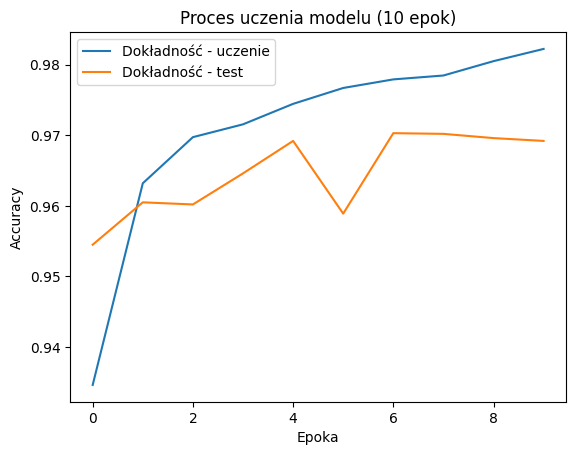

In [10]:
plt.plot(history.history['accuracy'], label='Dokładność - uczenie')
plt.plot(history.history['val_accuracy'], label='Dokładność - test')
plt.title('Proces uczenia modelu (10 epok)')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Zwiększenie liczby epok do 10 znacząco podniosło dokładność na zbiorze uczącym, lecz zastosowanie parametru batch_size=1 skutkowało bardzo niestabilnym procesem uczenia na zbiorze testowym. Rosnąca po 6. epoce rozbieżność między krzywymi świadczy o wystąpieniu przeuczenia się sieci.
  

--------------------------------------

7. Ustaw parametr validation_split, tak aby w trakcie uczenia 30 procent zbioru uczącego było
zbiorem do walidacji. Narysuj wykres procesu uczenia oraz podaj otrzymane wartości jakości
klasyfikacji dla zbioru testowego i uczącego

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9110 - loss: 0.3088 - val_accuracy: 0.9512 - val_loss: 0.1639
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9620 - loss: 0.1232 - val_accuracy: 0.9588 - val_loss: 0.1407
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9743 - loss: 0.0827 - val_accuracy: 0.9646 - val_loss: 0.1133
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9814 - loss: 0.0594 - val_accuracy: 0.9611 - val_loss: 0.1367
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9851 - loss: 0.0456 - val_accuracy: 0.9654 - val_loss: 0.1203
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9888 - loss: 0.0334 - val_accuracy: 0.9659 - val_loss: 0.1341
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9910 - loss: 0.0272 - val_accuracy: 0.9664 - val_loss: 0.1327
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9916 - loss: 0.0247 - 

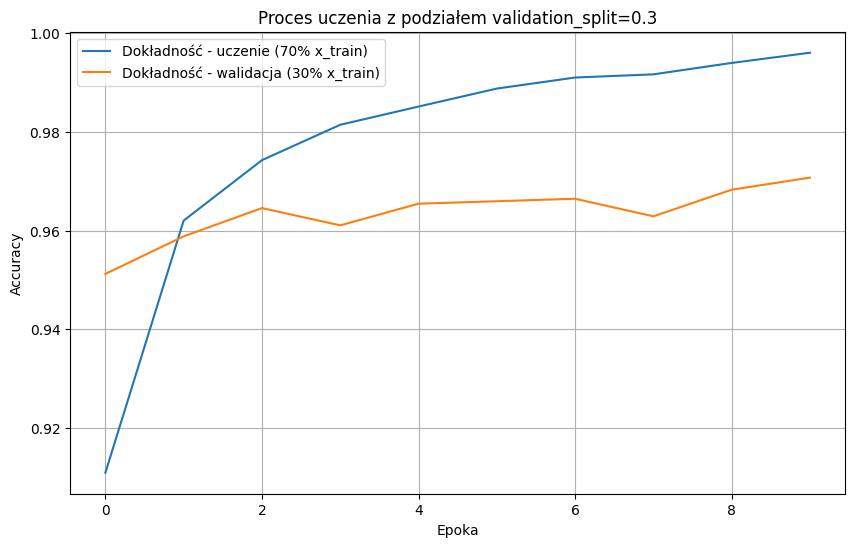

Jakość klasyfikacji dla zbioru uczącego (ostatnia epoka): 0.9960
Jakość klasyfikacji dla zbioru testowego (x_test): 0.9716


In [12]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, 
                    epochs=10, 
                    batch_size=32, 
                    validation_split=0.3,
                    verbose=1)

plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Dokładność - uczenie (70% x_train)')
plt.plot(history.history['val_accuracy'], label='Dokładność - walidacja (30% x_train)')
plt.title('Proces uczenia z podziałem validation_split=0.3')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"Jakość klasyfikacji dla zbioru uczącego (ostatnia epoka): {history.history['accuracy'][-1]:.4f}")
print(f"Jakość klasyfikacji dla zbioru testowego (x_test): {test_acc:.4f}")

Wprowadzenie validation_split=0.3 oraz zwiększenie batch_size do 32 znacząco wygładziło krzywe uczenia, zapewniając stabilniejsze uczenie modelu.

Uzyskano bardzo wysoka dokładność na zbiorze uczącym (0,9960) przy lekko niższym wyniku testowym (0,9716)

--------------------------------

8. Zmień liczbę neuronów w warstwach. Sprawdź wpływ tej operacji na działanie sieci.

In [16]:
konfiguracje = [32, 512]

for n_neurons in konfiguracje:
    print(f"\nModel z {n_neurons} neuronami w warstwach ukrytych")
    
    model = tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(n_neurons, activation='relu'),
        tf.keras.layers.Dense(n_neurons, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train, y_train, 
                        epochs=5, 
                        batch_size=32, 
                        validation_split=0.3,
                        verbose=1)

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    
    print(f"WYNIK DLA {n_neurons} NEURONÓW:")
    print(f"Accuracy (Uczenie): {history.history['accuracy'][-1]:.4f}")
    print(f"Accuracy (Test): {test_acc:.4f}")
    print(f"Różnica: {abs(history.history['accuracy'][-1] - test_acc):.4f}")


Model z 32 neuronami w warstwach ukrytych
Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 877us/step - accuracy: 0.8742 - loss: 0.4546 - val_accuracy: 0.9161 - val_loss: 0.2876
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 814us/step - accuracy: 0.9339 - loss: 0.2279 - val_accuracy: 0.9321 - val_loss: 0.2251
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 804us/step - accuracy: 0.9457 - loss: 0.1828 - val_accuracy: 0.9427 - val_loss: 0.1921
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 823us/step - accuracy: 0.9541 - loss: 0.1528 - val_accuracy: 0.9417 - val_loss: 0.1914
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 810us/step - accuracy: 0.9590 - loss: 0.1335 - val_accuracy: 0.9472 - val_loss: 0.1762
WYNIK DLA 32 NEURONÓW:
Accuracy (Uczenie): 0.9590
Accuracy (Test): 0.9520
Różnica: 0.0070

Model z 512 neuronami w warstwach ukrytych
Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9303 - loss: 0.2315 - val_accuracy: 0.9574 - val_loss: 0.1368
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━

Czy zmniejszenie/zwiększenie liczby neuronów miało wpływ na jakość klasyfikacji?  
- Zwiększenie ich liczby do 512 pozwoliło sieci na uchwycenie bardziej złożonych cech obrazów, co przełożyło się na wyższą precyzję końcową na obu zbiorach danych, jednak bardziej zaawansowana struktura sieci prowadziła do zwiększenia tendencji do overfittingu. 
- Zmniejszenie liczby neuronów do 32 ograniczyło możliwości sieci, co skutkowało niższą dokładnością, ale zapewniło większą spójność między wynikami uczącymi a testowymi.

----------------------------------

Zadanie nr 2

Na bazie zbioru MNIST przenalizuj wpływ parametru batch_size na szybkość uczenia oraz na jakość
klasyfikacji.

In [5]:
import time 

batches = [1, 64, 256, 1024]
results = {}

for b_size in batches:
    print(f"\n>>> Testowanie batch_size = {b_size} <<<")
    
    model = tf.keras.models.Sequential([
        tf.keras.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    start = time.time()
    
    history = model.fit(x_train, y_train, epochs=1, batch_size=b_size, verbose=1)
    
    end = time.time()
    duration = end - start
    
    _, test_acc = model.evaluate(x_test, y_test, verbose=0)
    
    results[b_size] = {'czas': duration, 'accuracy': test_acc}

print("\nWyniki")
for b, data in results.items():
    print(f"Batch {b:4} | Czas: {data['czas']:6.2f}s | Jakość: {data['accuracy']:.4f}")


>>> Testowanie batch_size = 1 <<<
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 38s 630us/step - accuracy: 0.7693 - loss: 1.6767

>>> Testowanie batch_size = 64 <<<
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 883us/step - accuracy: 0.8596 - loss: 3.3382 

>>> Testowanie batch_size = 256 <<<
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8642 - loss: 6.1266 

>>> Testowanie batch_size = 1024 <<<
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7642 - loss: 17.2229  

Wyniki
Batch    1 | Czas:  38.07s | Jakość: 0.7929
Batch   64 | Czas:   1.10s | Jakość: 0.8940
Batch  256 | Czas:   0.53s | Jakość: 0.9208
Batch 1024 | Czas:   0.51s | Jakość: 0.8897


Wnioski:

Zwiększenie batch_size drastycznie skraca czas uczenia  poprzez lepsze wykorzystanie mocy obliczeniowej i rzadszą aktualizację wag, jednak zbyt duże wartości mogą prowadzić do spadku precyzji i gorszej zbieżności modelu. Najlepszy balans między szybkością, a jakością klasyfikacji w powyższym badaniu zapewnia batch_size = 256, podczas gdy uczenie przyrostowe (batch_size=1) jest skrajnie nieefektywne czasowo i charakteryzuje się dużą niestabilnością wyników.

----------------------------------------------

Zadanie nr 3

Na bazie zbiorów danych: Dane1 oraz Dane2 oceń wpływ parametrów sieci neuronowych na
szybkość działania oraz jakość uzyskanych wyników. Należy spróbować tak dobrać parametry modeli,
aby uzyskać możliwie najlepszy wynik ich działania.


Należy wziąć pod uwagę różne wartości:
1. funkcji aktywacji (minimum 2 różne funkcje)
2. algorytmu uczenia sieci (minimum 2 algorytmy)
3. struktury sieci neuronowej (różne liczby neuronów i warstw)

Zastanowić się nad przygotowaniem eksperymentów i opisać sposób ich wykonania. Jak długo
powinniśmy uczyć sieci?

----------------------------

Pierwszy zbiór danych:

Sposób wykonania: Badanie polegać będzie na zastosowaniu metody Grid Search do oceny wpływu 27 kombinacji parametrów (architektura, funkcja aktywacji, optymalizator) na precyzję modelu. Sieć będzie przyjmować jedno wejście (x) i zwracać jedną wartość ciągłą. Czas uczenia zaplanowano na stałą liczbę 150 epok, co pozwoli na obserwację pełnej krzywej uczenia i wychwycenie momentu stabilizacji błędu (MSE). Przyjęta liczba epok ma zapewnić algorytmom o wolniejszej zbieżności (np. SGD) wystarczający czas na odnalezienie minimum globalnego.

In [9]:
import pandas as pd

d1_train = pd.read_csv('MLP_dane1_ucz.txt', sep='\t')
d1_test = pd.read_csv('MLP_dane1_test.txt', sep='\t')
d2 = pd.read_csv('MLP_dane2.txt', sep='\t')

X1_train = d1_train[['x']].values
y1_train = d1_train['y'].values
X1_test = d1_test[['x']].values
y1_test = d1_test['y'].values

from sklearn.model_selection import train_test_split
X2 = d2[['x1', 'x2']].values
y2 = d2['y'].values
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

print(f"Dane1: {len(X1_train)} próbek uczących.")
print(f"Dane2: {len(X2_train)} próbek uczących.")

Dane1: 300 próbek uczących.
Dane2: 120 próbek uczących.


Eksperyment dla Dane1:

3 NAJLEPSZE WYNIKI
MSE: 0.009441 | Str: [32, 32, 32], Akt: tanh, Opt: adam
MSE: 0.013159 | Str: [32, 32, 32], Akt: tanh, Opt: rmsprop
MSE: 0.147244 | Str: [32, 32, 32], Akt: relu, Opt: rmsprop

3 NAJGORSZE WYNIKI
MSE: 0.465374 | Str: [32, 32, 32], Akt: sigmoid, Opt: sgd
MSE: 0.468021 | Str: [32, 32, 32], Akt: sigmoid, Opt: rmsprop
MSE: 0.493070 | Str: [16], Akt: relu, Opt: sgd
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


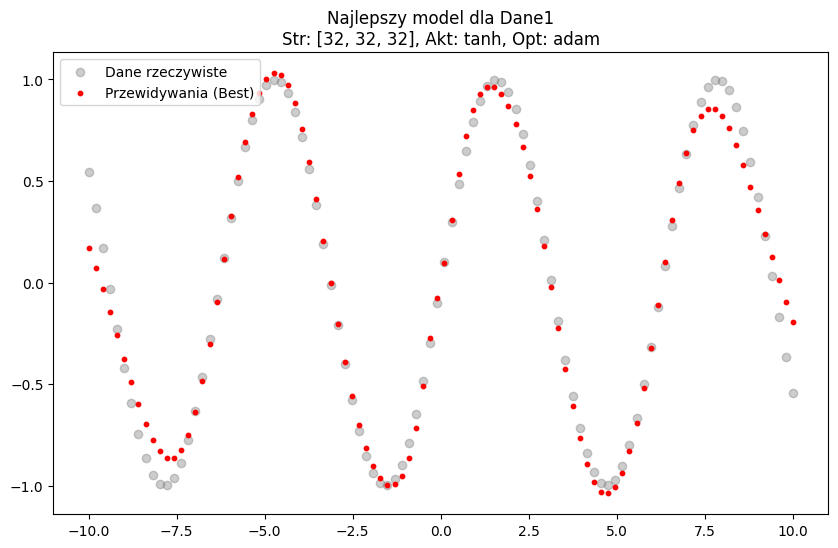

In [12]:
activations = ['relu', 'tanh', 'sigmoid']
optimizers = ['adam', 'sgd', 'rmsprop']
structures = [[16], [64, 64], [32, 32, 32]]

all_results = [] 

print("Eksperyment dla Dane1:")

for act in activations:
    for opt in optimizers:
        for struct in structures:
            model = tf.keras.models.Sequential([
                tf.keras.Input(shape=(1,)), 
                *[tf.keras.layers.Dense(n, activation=act) for n in struct],
                tf.keras.layers.Dense(1) 
            ])
            model.compile(optimizer=opt, loss='mse')
            model.fit(X1_train, y1_train, epochs=150, batch_size=32, verbose=0)
            mse = model.evaluate(X1_test, y1_test, verbose=0)
            all_results.append({
                'config': f"Str: {struct}, Akt: {act}, Opt: {opt}",
                'mse': mse,
                'model': model
            })

all_results.sort(key=lambda x: x['mse'])

print("\n3 NAJLEPSZE WYNIKI")
for res in all_results[:3]:
    print(f"MSE: {res['mse']:.6f} | {res['config']}")

print("\n3 NAJGORSZE WYNIKI")
for res in all_results[-3:]:
    print(f"MSE: {res['mse']:.6f} | {res['config']}")

best_res = all_results[0]
y_pred = best_res['model'].predict(X1_test)

plt.figure(figsize=(10, 6))
plt.scatter(X1_test, y1_test, color='gray', alpha=0.4, label='Dane rzeczywiste')
plt.scatter(X1_test, y_pred, color='red', s=10, label='Przewidywania (Best)')
plt.title(f"Najlepszy model dla Dane1\n{best_res['config']}")
plt.legend()
plt.show()

Najlepsze dopasowanie do zbioru Dane1 zapewniła struktura wielowarstwowa [32, 32, 32] wykorzystująca funkcję aktywacji tanh i optymalizator adam, co pozwoliło na uzyskanie błędu MSE na poziomie 0,0094. Eksperyment wykazał, że algorytmy adaptacyjne (adam, rmsprop) radzą sobie znacznie lepiej z problemem regresji niż klasyczny sgd, który przy zadanej liczbie epok wykazywał niską skuteczność. Funkcja sigmoid okazała się najmniej efektywna w tym zadaniu, generując najwyższe błędy ze względu na ograniczony zakres wartości i trudniejszą propagację gradientu w głębszych warstwach sieci

------------------------------------

Eksperyment dla drugiego zbioru: 

Sposób wykonania: Celem jest sprawdzenie zdolności sieci do modelowania powierzchni w przestrzeni 3D na podstawie dwóch cech wejściowych. Procedura przewiduje testowanie analogicznych zestawów parametrów przy zmodyfikowanej warstwie wejściowej (shape=(2,)). Długość procesu uczenia ustalono na 150 epok, przy czym kluczowym elementem będzie monitorowanie, czy zwiększona wymiarowość danych nie wymaga dłuższego czasu na osiągnięcie fazy plateau. Proces zostanie uznany za ukończony, gdy błąd na zbiorze walidacyjnym przestanie wykazywać trend spadkowy, co pozwoli uniknąć ryzyka przeuczenia modelu.

Eksperyment dla Dane2

3 NAJLEPSZE WYNIKI
MSE: 0.000246 | Str: [32, 32, 32], Akt: relu, Opt: adam
MSE: 0.000280 | Str: [64, 64], Akt: relu, Opt: adam
MSE: 0.000499 | Str: [64, 64], Akt: relu, Opt: rmsprop

3 NAJGORSZE WYNIKI
MSE: 0.220893 | Str: [16], Akt: sigmoid, Opt: sgd
MSE: 0.430830 | Str: [64, 64], Akt: sigmoid, Opt: sgd
MSE: 0.474648 | Str: [32, 32, 32], Akt: sigmoid, Opt: sgd
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


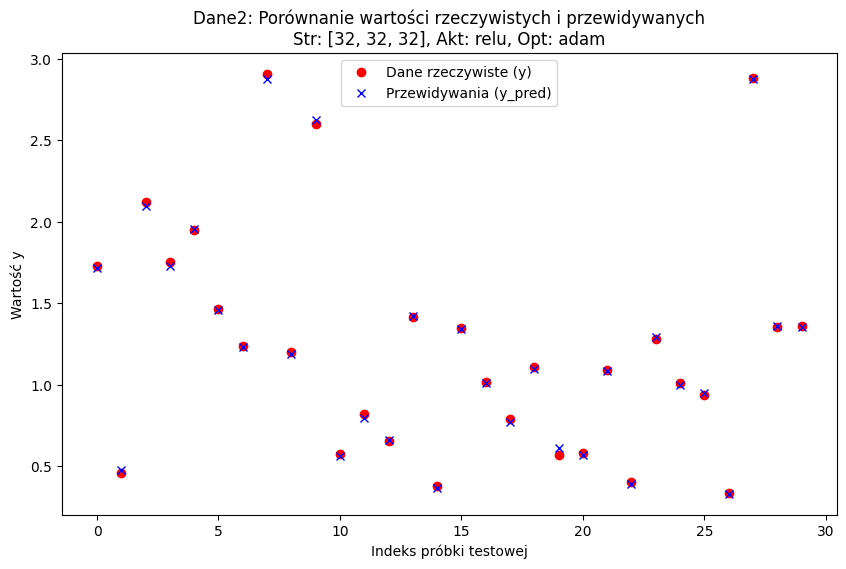

In [14]:
all_results_d2 = []

print("Eksperyment dla Dane2")

for act in activations:
    for opt in optimizers:
        for struct in structures:
            model = tf.keras.models.Sequential([
                tf.keras.Input(shape=(2,)), 
                *[tf.keras.layers.Dense(n, activation=act) for n in struct],
                tf.keras.layers.Dense(1)
            ])
            
            model.compile(optimizer=opt, loss='mse')
            model.fit(X2_train, y2_train, epochs=150, batch_size=16, verbose=0)
            mse = model.evaluate(X2_test, y2_test, verbose=0)
            all_results_d2.append({
                'config': f"Str: {struct}, Akt: {act}, Opt: {opt}",
                'mse': mse,
                'model': model
            })

all_results_d2.sort(key=lambda x: x['mse'])

print("\n3 NAJLEPSZE WYNIKI")
for res in all_results_d2[:3]:
    print(f"MSE: {res['mse']:.6f} | {res['config']}")

print("\n3 NAJGORSZE WYNIKI")
for res in all_results_d2[-3:]:
    print(f"MSE: {res['mse']:.6f} | {res['config']}")

best_res_d2 = all_results_d2[0]
y_pred_d2 = best_res_d2['model'].predict(X2_test)

plt.figure(figsize=(10, 6))
plt.plot(y2_test, label='Dane rzeczywiste (y)', color='red', marker='o', linestyle='')
plt.plot(y_pred_d2, label='Przewidywania (y_pred)', color='blue', marker='x', linestyle='')
plt.title(f"Dane2: Porównanie wartości rzeczywistych i przewidywanych\n{best_res_d2['config']}")
plt.xlabel('Indeks próbki testowej')
plt.ylabel('Wartość y')
plt.legend()
plt.show()

W eksperymencie dla zbioru Dane2 najwyższą jakość predykcji uzyskała głęboka struktura [32, 32, 32] z funkcją aktywacji relu i optymalizatorem adam, osiągając błąd błędu średniokwadratowego (MSE) na poziomie 0,000246. Wyniki jednoznacznie potwierdzają, że funkcje typu sigmoid oraz algorytmy oparte na prostym spadku gradientu (sgd) są nieefektywne w zadaniach regresji wielowymiarowej, generując błędy o kilka rzędów wielkości wyższe niż metody adaptacyjne. Niemal idealne pokrycie się wartości rzeczywistych i przewidywanych na wykresie dowodzi, że właściwy dobór parametrów pozwolił sieci na pełne odtworzenie nieliniowej powierzchni opisującej dane wejściowe.